# Optimizing the Class Weight Directly

Three notebooks have now chosen a class weight three ways: by sweeping a grid and reading a plot, by
pricing the outcomes with a reward matrix, and by sampling the simplex at random. All of them
evaluate a fixed set of candidates and keep the best.

This one hands the job to an actual **optimizer**. `scipy.optimize.minimize_scalar` searches the
weight range for the value maximizing cross-validated reward, choosing where to look next based on
what it has already seen instead of walking a predetermined list.

## Learning objectives

- Wrap a cross-validated business metric into an objective function for an optimizer
- Use `minimize_scalar` with bounds to tune a single continuous hyperparameter
- Explain why a derivative-free method is required when the objective is a step function
- Distinguish selecting a value from *illustrating* the landscape it was selected from

## Background

This notebook assumes class weights and the reward matrix from `U1-7_Imbalance-4_ClassWeights` —
the reward matrix is the same one, so the two notebooks are directly comparable — plus
cross-validation with `StratifiedKFold`.

`scipy.optimize.minimize_scalar` is used as a black box: given a function of one variable and
bounds, it returns the minimizing input.

**Prerequisites:** `U1-7_Imbalance-4_ClassWeights` (class weights and the reward matrix),
`U1-7_Imbalance-1_StratifiedKFold`

**Dataset:** none — two 2-D Gaussian clouds from `GenerateData`, at 1000:250 (4:1).

**References:** https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize_scalar.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Tools: entropy, region painting, and the data generator

Three helpers carried across the imbalance notebooks.

`GenerateData(n_pts0, n_pts1, center_sep, std)` draws two 2-D Gaussian clouds with a controllable
**imbalance ratio** — the two counts are independent, so a 10:1 or 4:1 split is one argument away —
and a controllable **overlap** via `center_sep` and `std`. Imbalance and overlap are separate
problems and this lets us vary them separately.

`entropy` and `visualize_regions` are the decision-region tools from
`U1-6_Classify-1_CompareRegions`: predict on a dense grid, reshape into an image, and return both
the predicted class and the entropy of the predicted probabilities at each point.

In [2]:
import math

def entropy( x, b ):
    s = 0
    for p in x:
        if p > 0:
            s += -p*math.log(p,b)
        # end
    # end
    return s
# end

def visualize_regions(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)

    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T

    # Predict B
    B = model.predict(A)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)

    # Compute entropy for S
    prob_2D = model.predict_proba(A)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)

    return B, S
# end
    
def GenerateData(n_pts1,n_pts2,center_sep,std):
    
    cov = std**2*np.eye(2)
    
    x1 = np.random.multivariate_normal(mean=[-center_sep/2,0],
                                       cov=cov,
                                       size=n_pts1)
    y1 = np.zeros(n_pts1)
    
    x2 = np.random.multivariate_normal(mean=[center_sep/2,0],
                                       cov=cov,
                                       size=n_pts2)
    y2 = np.ones(n_pts2)
    
    X = np.concatenate((x1,x2),axis=0)
    y = np.concatenate((y1,y2),axis=0).astype(int)
    
    return X, y
# end

## 2. Create the data

The same 4:1 clouds as `U1-7_Imbalance-4_ClassWeights`, so the weight the optimizer finds can be
compared against the one the sweep found by eye.

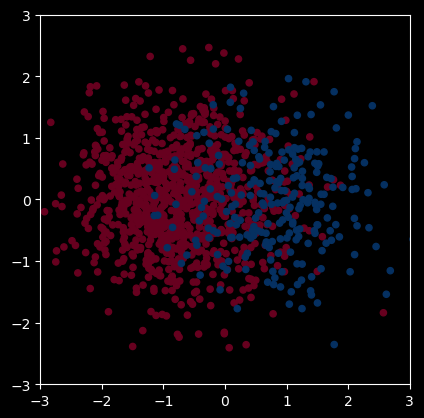

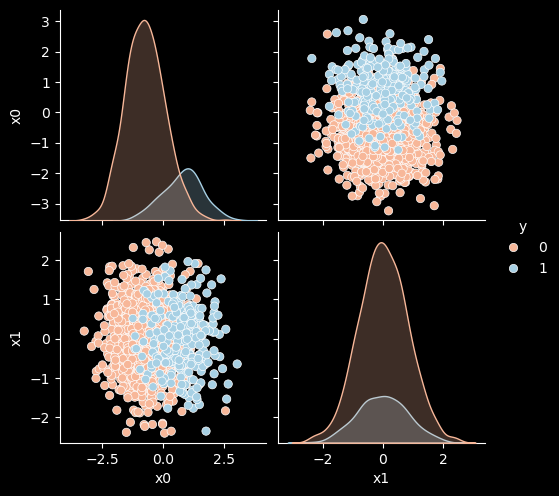

In [3]:
#np.random.seed(0)

n_pts0     = 1000
n_pts1     = 250
std        = 0.8
center_sep = 1.5

# generate data
X, y = GenerateData(
    n_pts0,
    n_pts1,
    center_sep,
    std
)

MAX = np.max(np.abs(X))

cmap = 'RdBu'

plt_scale = 3
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap=cmap)
plt.xlim(-plt_scale,plt_scale)
plt.ylim(-plt_scale,plt_scale)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame( {"x0":X[:,0], "x1":X[:,1], "y":y} )
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## 3. Optimize the class weight with SciPy

Instead of manually sweeping the class weight, we let a SciPy optimizer search
for the weight that maximizes the **business reward** (via the reward matrix),
scored by cross-validation.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

### 3.1 The objective function

Three ideas are composed in the cell below.

**The reward matrix** prices each confusion-matrix cell, exactly as in
`U1-7_Imbalance-4_ClassWeights`, and `reward_score` reduces a set of predictions to one number:
$\text{reward} = \sum_{ij} C_{ij} R_{ij}$.

**Cross-validation** wraps that score so the objective is not measured on a single split. Without
it the optimizer would happily tune the weight to whichever split it was given — overfitting the
hyperparameter rather than the parameters.

**Negation** turns maximization into minimization, since `minimize_scalar` minimizes. This is the
mirror image of the `neg_mean_absolute_error` convention in `scoring`, where sklearn negates because
it always maximizes.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, confusion_matrix, classification_report
from scipy.optimize import minimize_scalar

# Business reward matrix (rows = true, cols = predicted)
#   TN ->     0   (correctly decline)
#   FP -> -5000   (loan to someone who defaults: expensive)
#   FN ->  -100   (decline a good customer: small opportunity cost)
#   TP ->  1000   (loan to someone who repays: profit)
reward_matrix = np.array(
    [[   0, -5000],
     [-100,  1000]]
)

def reward_score(y_true, y_pred):
    conf = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return (conf * reward_matrix).sum()
# end

# greater reward is better; wrap so cross_val_score can use it
reward_scorer = make_scorer(reward_score, greater_is_better=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

def neg_cv_reward(w):
    # w is the positive-class weight; negative class gets 1-w
    model = LogisticRegression(class_weight={0: 1 - w, 1: w})
    scores = cross_val_score(model, X_train, y_train,
                             scoring=reward_scorer, cv=cv)
    return -scores.mean()   # negate: minimize_scalar minimizes
# end

### 3.2 Run the optimizer

`method='bounded'` selects a **derivative-free** algorithm, and the comment in the cell explains
why that is not optional: reward as a function of $w$ is a **step function**. Predicted labels only
change when the shifting decision boundary crosses an actual data point, so the confusion matrix —
and therefore the reward — is piecewise constant. Its derivative is zero almost everywhere and
undefined at the jumps, which defeats any gradient-based method.

The bounds exclude exactly 0 and 1, which would zero out one class's weight entirely and remove that
class from the loss.

One consequence of the step structure worth stating: the objective has flat plateaus, so a range of
$w$ values gives identical reward. The optimizer returns one point from the winning plateau rather
than a unique optimum — which is fine, and is also why the landscape plot below is worth looking at.

In [6]:
# reward-vs-w is a step function, so use a derivative-free bounded optimizer.
# Bounds avoid w=0 / w=1, which would zero-out a class weight entirely.
res = minimize_scalar(neg_cv_reward, bounds=(1e-3, 1 - 1e-3), method='bounded')

w_opt = res.x
print(res)
print()
print("Optimal positive-class weight w:", w_opt)
print("Best CV average reward:", -res.fun)

 message: Solution found.
 success: True
  status: 0
     fun: -5800.0
       x: 0.3014807805512975
     nit: 25
    nfev: 25

Optimal positive-class weight w: 0.3014807805512975
Best CV average reward: 5800.0


### 3.3 Evaluate at the chosen weight

Refit at $w_{\text{opt}}$ and score on the held-out test set — data the optimizer never saw, since
it worked only from cross-validation *within* the training split. The test reward is the honest
estimate of what this choice is worth.

LogisticRegression(class_weight={0: np.float64(0.6985192194487024),
                                 1: np.float64(0.3014807805512975)})
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       200
           1       0.65      0.26      0.37        50

    accuracy                           0.82       250
   macro avg       0.74      0.61      0.63       250
weighted avg       0.80      0.82      0.79       250

Test-set reward: -25700


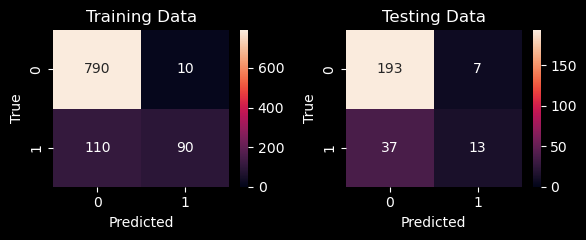

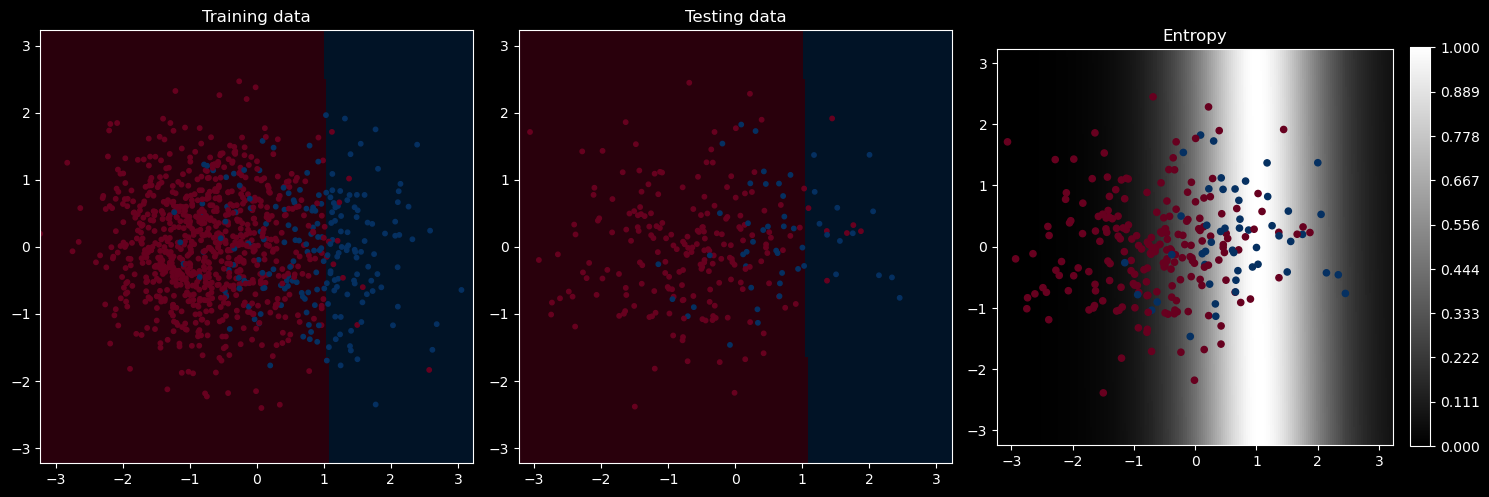

In [7]:
# Fit the final model at the optimal weight and evaluate on the held-out test set
model = LogisticRegression(class_weight={0: 1 - w_opt, 1: w_opt})
model.fit(X_train, y_train)
print(model)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print(classification_report(y_test, y_test_pred))
print("Test-set reward:", reward_score(y_test, y_test_pred))

conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
conf_matrix_test  = confusion_matrix(y_test, y_test_pred).astype(int)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Training Data")
sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Testing Data")
plt.tight_layout()
plt.show()

B, S = visualize_regions(model, MAX, 200)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
extent = [-MAX,MAX,-MAX,MAX]
cmap = "RdBu"

axes[0].imshow(B, interpolation='none', extent=extent, cmap=cmap, alpha=0.4)
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
axes[0].set_aspect('equal')
axes[0].set_title('Training data');

axes[1].imshow(B, interpolation='none', extent=extent, cmap=cmap, alpha=0.4)
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
axes[1].set_aspect('equal')
axes[1].set_title('Testing data');

im = axes[2].imshow(S, interpolation='none', extent=extent, cmap='gray')
axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
axes[2].set_aspect('equal')
axes[2].set_title('Entropy')
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

plt.tight_layout()
plt.show()

### 3.4 (Optional) Reward landscape — illustration only

This plot evaluates the objective across a grid of `w` purely to *see* the
landscape the optimizer searched. It is **not** used to select the weight —
that was done by the optimizer above.

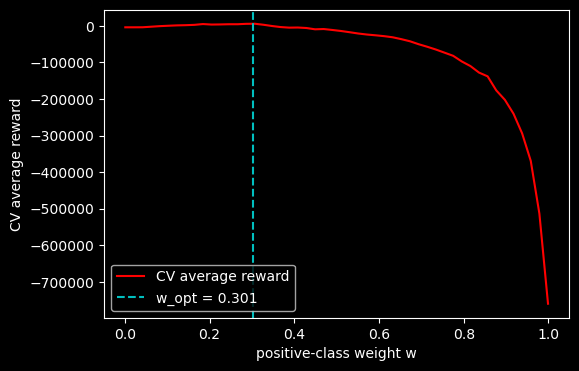

In [8]:
w_grid = np.linspace(1e-3, 1 - 1e-3, 50)
rewards_grid = np.array([-neg_cv_reward(w) for w in w_grid])

plt.figure(figsize=(6,4))
plt.plot(w_grid, rewards_grid, 'r', label='CV average reward')
plt.axvline(w_opt, color='c', ls='--', label=f'w_opt = {w_opt:.3f}')
plt.xlabel('positive-class weight w')
plt.ylabel('CV average reward')
plt.legend()
plt.show()

The staircase shape is the step function described above, and the flat top confirms the plateau —
several values of $w$ are equally good, and the optimizer landed on one of them.

Note the discipline the existing comment insists on: this grid is drawn **after** the choice was
made, purely to visualize what the optimizer searched. Selecting the weight by eye from this plot
would be a different method — the one from `U1-7_Imbalance-4_ClassWeights` — and mixing the two
would make it impossible to say which actually chose the answer.

## 4. Inverse-frequency weights, for comparison

The `'balanced'` default again, as a baseline against the optimized weight. Compare their test
rewards: `'balanced'` equalizes class influence, while the optimizer targeted the reward matrix
directly, so the optimized weight should win on reward — and may well lose on $F_1$. Each is optimal
for the objective it was given.

## Inverse frequency class weights

{0: np.float64(0.2), 1: np.float64(0.8)}
LogisticRegression(class_weight='balanced')
              precision    recall  f1-score   support

           0       0.95      0.79      0.86       200
           1       0.49      0.84      0.62        50

    accuracy                           0.80       250
   macro avg       0.72      0.81      0.74       250
weighted avg       0.86      0.80      0.81       250



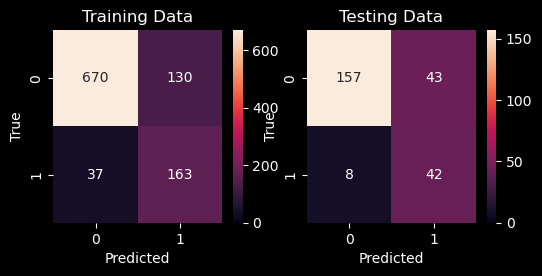

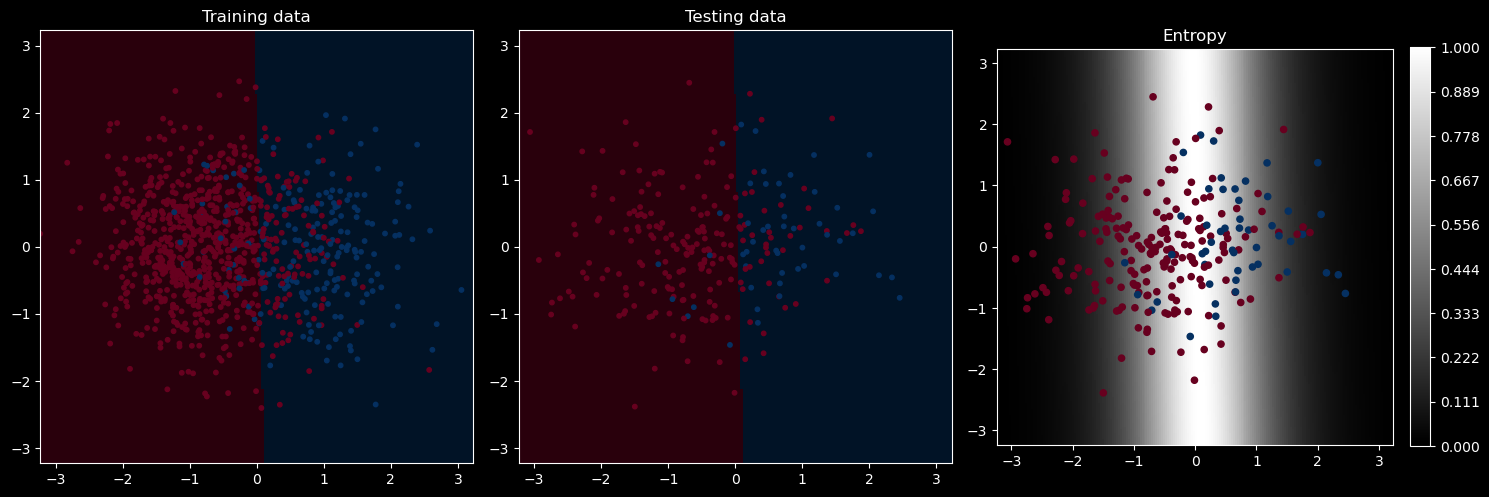

In [9]:
class_weight = np.array([1.0/n_pts0, 1.0/n_pts1])
class_weight = class_weight / class_weight.sum()
class_weight = { 0:class_weight[0], 1:class_weight[1] }
print(class_weight)

model = LogisticRegression(
    #class_weight=class_weight
    class_weight='balanced'
)

model.fit(X_train, y_train)
print(model)

y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

print(classification_report(y_test, y_test_pred))

conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Training Data")

sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Testing Data")

plt.show()

B, S = visualize_regions(model, MAX, 200)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

extent = [-MAX,MAX,-MAX,MAX]

cmap = "RdBu"
axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
axes[0].set_aspect('equal')
axes[0].set_title('Training data');

axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
axes[1].set_aspect('equal')
axes[1].set_title('Testing data');

im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
axes[2].set_aspect('equal')
axes[2].set_title('Entropy')
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

plt.tight_layout()
plt.show()

## 5. Review

- **An optimizer chooses where to look next**, unlike a sweep or a random search over a fixed
  candidate list.
- **The objective must be cross-validated**, or the weight is tuned to one arbitrary split.
- **Negate to minimize**, the same convention as sklearn's `neg_*` scorers in reverse.
- **Reward is a step function of the weight** — labels change only when the boundary crosses a data
  point — so a derivative-free method such as `method='bounded'` is required, and the objective has
  flat plateaus rather than a unique optimum.
- **Plot the landscape after choosing, not before**, and keep the two activities distinct.
- **Every method here optimizes the objective it was handed.** The reward-optimal weight and the
  $F_1$-optimal weight are different answers to different questions.